# A5 -- Calibration analysis (Supplementary Table S4 + Figure S1)

This notebook reproduces the calibration results reported in Supplementary Section S5.
Confidence is the maximum class probability `p_max`; a prediction is scored *correct* when its
argmax matches the reference label (rating-derived agreement for the **gpt-4o-mini annotator**;
the panel target label for the **downstream ALBERT probe**). Expected and maximum calibration
error (**ECE/MCE**) use **15 equal-width bins** of `p_max`.

**Inputs.** Panel A reads the labeled study CSVs (`ai_prob_*`, `sentiment_5`) archived at OSF, placed
under `./data/PureText/` (text-only annotation) and `./data/Text_Metadata/` (text+metadata annotation).
Panel B reads the held-out ALBERT test predictions (`albert_prob_*`, `albert_pred_id`, `true_label_id`)
exported by the T-notebooks (text-only prediction probes) into `./data/predictions/`.

In [1]:
# A5 -- Calibration analysis (Supplementary Table S4 + Figure S1)
# Reproduces expected and maximum calibration error (ECE/MCE) with 15 equal-width
# confidence bins for (A) the gpt-4o-mini annotator and (B) the downstream ALBERT probe.
try:
    from google.colab import drive  # Colab only
except Exception:
    drive = None
import os as _os
if drive is not None and not _os.path.ismount("/content/drive"):
    drive.mount("/content/drive")  # optional; all data paths are relative to DrugReview_ROOT

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DrugReview_ROOT = Path(".")
DATA = os.path.join(DrugReview_ROOT, "data")

ORDER5 = ["very_negative", "negative", "neutral", "positive", "very_positive"]
IDX5 = {c: i for i, c in enumerate(ORDER5)}
PROB_COLS = ["ai_prob_very_negative", "ai_prob_negative", "ai_prob_neutral",
             "ai_prob_positive", "ai_prob_very_positive"]
N_BINS = 15  # 15 equal-width bins of p_max, per Supplementary Section S5

In [2]:
def calibration(pmax, correct, n_bins=N_BINS):
    """ECE/MCE over n_bins equal-width bins of p_max in [0, 1].
    correct: 0/1 array (prediction matches its reference label). Returns
    (accuracy, mean p_max, overconfidence, ECE, MCE)."""
    pmax = np.asarray(pmax, float); correct = np.asarray(correct, float)
    acc, conf = correct.mean(), pmax.mean()
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0; mce = 0.0
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        m = (pmax > lo) & (pmax <= hi) if b > 0 else (pmax >= lo) & (pmax <= hi)
        if m.sum() == 0:
            continue
        gap = abs(correct[m].mean() - pmax[m].mean())
        ece += m.mean() * gap
        mce = max(mce, gap)
    return acc, conf, conf - acc, ece, mce

def reliability_points(pmax, correct, n_bins=N_BINS):
    pmax = np.asarray(pmax, float); correct = np.asarray(correct, float)
    edges = np.linspace(0.0, 1.0, n_bins + 1); xs = []; ys = []
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        m = (pmax > lo) & (pmax <= hi) if b > 0 else (pmax >= lo) & (pmax <= hi)
        if m.sum() == 0:
            continue
        xs.append(pmax[m].mean()); ys.append(correct[m].mean())
    return np.array(xs), np.array(ys)

## Panel A -- gpt-4o-mini annotator calibration vs. rating agreement

In [4]:
# ---- Panel A: gpt-4o-mini annotator confidence vs. rating-derived agreement ----
# A prediction is "correct" when the probability-argmax label equals the rating-derived label.
PANEL_A_FILES = {
    ("Mood/Anxiety",  "Text-only"):     "PureText/drugsCom_mood_anxiety_with_ai_labels_mini.csv",
    ("Mood/Anxiety",  "Text+metadata"): "Text_Metadata/drugsCom_mood_anxiety_with_ai_labels_mini.csv",
    ("Heterogeneous", "Text-only"):     "PureText/drugsCom_generalized_with_ai_labels_mini.csv",
    ("Heterogeneous", "Text+metadata"): "Text_Metadata/drugsCom_generalized_with_ai_labels_mini.csv",
}
rowsA = []; storeA = {}
for (cohort, regime), rel in PANEL_A_FILES.items():
    df = pd.read_csv(os.path.join(DATA, rel))
    P = df[PROB_COLS].to_numpy(float); P = P / P.sum(1, keepdims=True)
    pmax = P.max(1); argmax = P.argmax(1)
    rating = df["sentiment_5"].str.lower().map(IDX5).to_numpy()
    correct = (argmax == rating).astype(float)
    acc, conf, over, ece, mce = calibration(pmax, correct)
    rowsA.append([cohort, regime, len(df), round(acc,3), round(conf,3), round(over,3), round(ece,3), round(mce,3)])
    storeA[(cohort, regime)] = reliability_points(pmax, correct)
panelA = pd.DataFrame(rowsA, columns=["Cohort","Annotation","N","Accuracy","Mean p_max","Overconf.","ECE","MCE"])
print("Supplementary Table S4 -- Panel A (gpt-4o-mini annotation confidence vs. rating agreement)")
print(panelA.to_string(index=False))

Supplementary Table S4 -- Panel A (gpt-4o-mini annotation confidence vs. rating agreement)
       Cohort    Annotation     N  Accuracy  Mean p_max  Overconf.   ECE   MCE
 Mood/Anxiety     Text-only 28755     0.571       0.497     -0.074 0.100 0.289
 Mood/Anxiety Text+metadata 28755     0.584       0.500     -0.083 0.106 0.461
Heterogeneous     Text-only 28755     0.535       0.491     -0.044 0.105 0.296
Heterogeneous Text+metadata 28755     0.532       0.489     -0.043 0.103 0.320


## Panel B -- downstream ALBERT probe calibration vs. panel target

In [6]:
# ---- Panel B: downstream ALBERT probe confidence vs. its panel target label ----
# Reads the held-out ALBERT test predictions (albert_prob_*, albert_pred_id, true_label_id)
# exported by the corresponding T-notebooks (text-only prediction probes; Tables III-IV).
ALB_PROB = ["albert_prob_VERY_NEGATIVE","albert_prob_NEGATIVE","albert_prob_NEUTRAL",
            "albert_prob_POSITIVE","albert_prob_VERY_POSITIVE"]
PANEL_B_FILES = {
    ("Mood/Anxiety",  "A rating-derived"):   "predictions/mood_rating_dl_models_predictions.csv",
    ("Mood/Anxiety",  "B AI text-only"):     "predictions/mood_ai_to_dl_models_predictions.csv",
    ("Mood/Anxiety",  "C AI text+metadata"): "predictions/mood_ai_tm_dl_models_predictions.csv",
    ("Heterogeneous", "A rating-derived"):   "predictions/het_rating_dl_models_predictions.csv",
    ("Heterogeneous", "B AI text-only"):     "predictions/het_ai_to_dl_models_predictions.csv",
    ("Heterogeneous", "C AI text+metadata"): "predictions/het_ai_tm_dl_models_predictions.csv",
}
rowsB = []; storeB = {}
for (cohort, panel), rel in PANEL_B_FILES.items():
    df = pd.read_csv(os.path.join(DATA, rel))
    P = df[ALB_PROB].to_numpy(float); P = P / P.sum(1, keepdims=True)
    pmax = P.max(1)
    correct = (df["albert_pred_id"].to_numpy() == df["true_label_id"].to_numpy()).astype(float)
    acc, conf, over, ece, mce = calibration(pmax, correct)
    rowsB.append([cohort, panel, len(df), round(acc,3), round(conf,3), round(over,3), round(ece,3), round(mce,3)])
    storeB[(cohort, panel)] = reliability_points(pmax, correct)
panelB = pd.DataFrame(rowsB, columns=["Cohort","Label panel","N","Accuracy","Mean p_max","Overconf.","ECE","MCE"])
print("Supplementary Table S4 -- Panel B (ALBERT downstream-probe confidence vs. panel target)")
print(panelB.to_string(index=False))

Supplementary Table S4 -- Panel B (ALBERT downstream-probe confidence vs. panel target)
       Cohort        Label panel    N  Accuracy  Mean p_max  Overconf.   ECE   MCE
 Mood/Anxiety   A rating-derived 5698     0.625       0.731      0.107 0.107 0.261
 Mood/Anxiety     B AI text-only 5698     0.726       0.842      0.115 0.116 0.275
 Mood/Anxiety C AI text+metadata 5698     0.727       0.867      0.140 0.142 0.390
Heterogeneous   A rating-derived 5744     0.627       0.601     -0.026 0.063 0.183
Heterogeneous     B AI text-only 5744     0.689       0.736      0.047 0.054 0.173
Heterogeneous C AI text+metadata 5744     0.689       0.893      0.205 0.205 0.370


## Figure S1 -- reliability diagrams

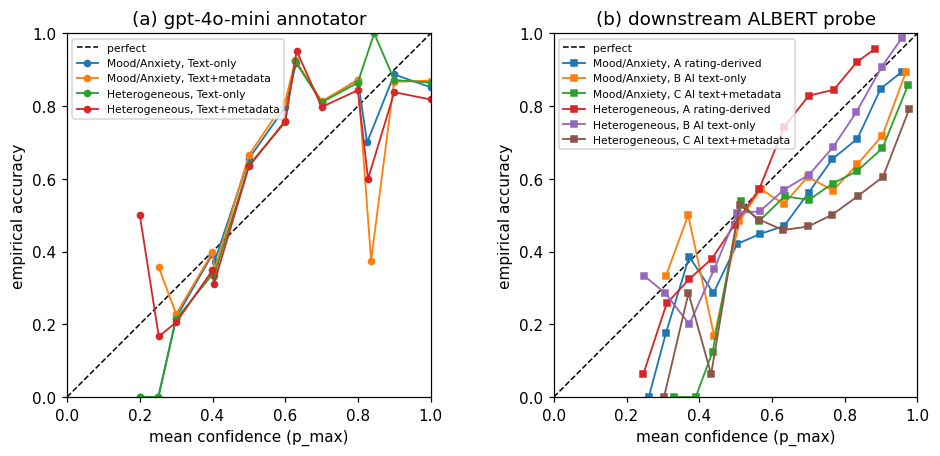

In [8]:
# ---- Figure S1: reliability diagrams (empirical accuracy vs. mean confidence) ----
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].plot([0,1],[0,1], "k--", lw=1, label="perfect")
for (cohort, regime), (xs, ys) in storeA.items():
    ax[0].plot(xs, ys, marker="o", ms=4, lw=1.2, label=f"{cohort}, {regime}")
ax[0].set_title("(a) gpt-4o-mini annotator")
ax[0].set_xlabel("mean confidence (p_max)"); ax[0].set_ylabel("empirical accuracy")
ax[0].legend(fontsize=7, loc="upper left")

ax[1].plot([0,1],[0,1], "k--", lw=1, label="perfect")
for (cohort, panel), (xs, ys) in storeB.items():
    ax[1].plot(xs, ys, marker="s", ms=4, lw=1.2, label=f"{cohort}, {panel}")
ax[1].set_title("(b) downstream ALBERT probe")
ax[1].set_xlabel("mean confidence (p_max)"); ax[1].set_ylabel("empirical accuracy")
ax[1].legend(fontsize=7, loc="upper left")
for a in ax:
    a.set_xlim(0,1); a.set_ylim(0,1); a.set_aspect("equal")
fig.tight_layout()
fig.savefig("fig_calibration.pdf", bbox_inches="tight")
plt.show()